# User Guide

Every `nuclearff` CLI command and what it builds, in the order you'd actually reach for them. Mirrors the [User Guide](https://nolmacdonald.github.io/nuclearff/user_guide.html) docs page. Every example below runs against real Sleeper data -- `1367225133634191360` (`NUCLEARFF REDRAFT`, this project's running example) for most sections, plus two other real leagues on the same account where the running example doesn't fit (a real completed playoff season, and a real auction draft).

Run `00_getting_started.ipynb` first if you haven't -- this notebook assumes `./demo` already has a config and continues building on it.

## Command groups

Every command reads a configuration file and writes beneath `paths.root` (`--root`, which is how every example here keeps its output under `examples/demo/` instead of your real project data).

In [1]:
!uv run nuclearff --help

usage: nuclearff [-h] [--version] [-c CONFIG] [--root ROOT]
                 [--log-level {DEBUG,INFO,WARNING,ERROR,CRITICAL}]
                 <group> ...

League-aware fantasy football research and valuation.

positional arguments:
  <group>
    config              Inspect and create configuration
    sleeper             Read-only Sleeper API access
    ids                 Cross-source player identity resolution
    report              Build draft boards and reports

options:
  -h, --help            show this help message and exit
  --version             show program's version number and exit
  -c, --config CONFIG   Configuration file (default: configs/nuclearff.yaml
                        when present)
  --root ROOT           Override paths.root; every managed directory resolves
                        beneath it
  --log-level {DEBUG,INFO,WARNING,ERROR,CRITICAL}
                        Console log level (default: the configured
                        run.log_level)


## Capturing a league

The starting point for everything else is a league snapshot. This writes every raw endpoint to an immutable, timestamped directory (never overwritten) and a typed `LeagueConfig` YAML derived from the league's scoring and roster settings. "Settings to review" flags real settings that are internally inconsistent or otherwise worth a second look -- both warnings below are real for this league, not illustrative.

In [2]:
!uv run nuclearff --root ./demo sleeper fetch-league --league-id 1367225133634191360

2026-09-09T23:17:13 [INFO] nuclearff.sleeper.snapshot: Wrote Sleeper snapshot to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/raw/sleeper/1367225133634191360/20260910T061713Z
League:   NUCLEARFF REDRAFT (1367225133634191360)
Season:   2026 status=in_season
Teams:    10
Snapshot: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/raw/sleeper/1367225133634191360/20260910T061713Z
League config: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/configs/leagues/1367225133634191360.yaml

Settings to review:
  [WARNING] draft_rounds_mismatch: League settings report draft_rounds=3 but the draft object reports rounds=15.
           -> Trust the draft object. The league field is stale; use 15 rounds for pick-gap and VONA math.
  [WARNING] keepers_in_redraft: League type is 0 (redraft) but max_keepers=1.
           -> Treat the league as redraft, but confirm in the Sleeper UI whether a keeper is actually in play.
  [INFO] median_scoring: Each team also pla

## Multi-season history

Sleeper links a league to its prior season via `previous_league_id`. `--history` walks that chain all the way back -- for this league, all the way to its real 2021 inception, six real seasons. Two tables land in DuckDB: `sleeper_leagues` (raw settings/scoring/roster JSON per season) and `sleeper_league_configs` (the same data, typed and flattened).

In [3]:
!uv run nuclearff --root ./demo sleeper fetch-league --league-id 1367225133634191360 --history

2026-09-09T23:17:17 [INFO] nuclearff.sleeper.leagues: Wrote 6 Sleeper league(s) (6 with a parsed config) to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/cache/nuclearff.duckdb
2026-09-09T23:17:17 [INFO] nuclearff.sleeper.snapshot: Wrote Sleeper snapshot to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/raw/sleeper/1367225133634191360/20260910T061715Z
League:   NUCLEARFF REDRAFT (1367225133634191360)
Season:   2026 status=in_season
Teams:    10
Snapshot: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/raw/sleeper/1367225133634191360/20260910T061715Z
League config: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/configs/leagues/1367225133634191360.yaml

Settings to review:
  [WARNING] draft_rounds_mismatch: League settings report draft_rounds=3 but the draft object reports rounds=15.
           -> Trust the draft object. The league field is stale; use 15 rounds for pick-gap and VONA math.
  [WARNING] keepers_in_redraft: Leagu

## Standings and playoff results

`--standings` computes, per season, each roster's regular-season record *and* where they actually finished after the playoffs -- genuinely different things. In this league's real 2025 season, the best regular-season record (20-8) finished **4th**; the eventual champion had fewer wins (16-12) and won it in the playoffs.

In [4]:
!uv run nuclearff --root ./demo sleeper fetch-league --league-id 1367225133634191360 --standings

2026-09-09T23:17:23 [INFO] nuclearff.sleeper.standings: Wrote 60 standings row(s) and 66 playoff match row(s) to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/cache/nuclearff.duckdb
2026-09-09T23:17:23 [INFO] nuclearff.sleeper.snapshot: Wrote Sleeper snapshot to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/raw/sleeper/1367225133634191360/20260910T061718Z
League:   NUCLEARFF REDRAFT (1367225133634191360)
Season:   2026 status=in_season
Teams:    10
Snapshot: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/raw/sleeper/1367225133634191360/20260910T061718Z
League config: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/configs/leagues/1367225133634191360.yaml

Settings to review:
  [WARNING] draft_rounds_mismatch: League settings report draft_rounds=3 but the draft object reports rounds=15.
           -> Trust the draft object. The league field is stale; use 15 rounds for pick-gap and VONA math.
  [WARNING] keepers_in_redraft: 

In [5]:
import duckdb

DB = "./demo/data/cache/nuclearff.duckdb"

with duckdb.connect(DB, read_only=True) as conn:
    rows = conn.execute("""
        SELECT display_name, wins, losses, regular_season_rank, final_rank
        FROM sleeper_standings
        WHERE league_id = '1240509989819273216'
        ORDER BY COALESCE(final_rank, 999)
    """).fetchall()
rows

[('nolmacdonald', 16, 12, 2, 1),
 ('ksavabi', 14, 14, 6, 2),
 ('nawfeastdallas', 15, 13, 5, 3),
 ('casitzmann', 20, 8, 1, 4),
 ('thatbolb', 16, 12, 4, 5),
 ('jwhitney0220', 16, 12, 3, 6),
 ('hyoga10', 11, 17, 9, None),
 ('aperry151', 11, 17, 8, None),
 ('Donkeysride', 12, 16, 7, None),
 ('ruhbberduhcky', 9, 19, 10, None)]

**A real DuckDB gotcha worth knowing**: reconnect fresh (`with duckdb.connect(DB, read_only=True) as conn:`) before every query in this notebook, rather than opening one connection at the top and reusing it -- a read-only connection opened before a later `!uv run nuclearff ...` cell writes a *new* table doesn't see that table until you reconnect. Each query cell below reconnects for exactly this reason.

Final placement is deliberately conservative: computed only from winners-bracket matches carrying a `p` (placement) field -- a match's winner gets rank `p`, its loser `p + 1`. The losers bracket's own placement field is captured raw but never turned into a guessed `final_rank`, since its numbering convention couldn't be confirmed against real data.

## Playoff bracket visualization

`report playoff-bracket` renders a completed season's winners and losers brackets as horizontal tree PNGs. That's this league's real, completed 2025 season below: 7 winners-bracket matches and 4 losers-bracket matches. Each leaf is labeled with the real team display name; the winner of each match renders bold; a match carrying a placement appends the resulting rank (e.g. `nolmacdonald (1st)`).

In [6]:
!uv run nuclearff --root ./demo report playoff-bracket 1240509989819273216 --season 2025 --league-name "NUCLEARFF REDRAFT"

2026-09-09T23:17:24 [INFO] nuclearff.report.bracket: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1240509989819273216-2025/brackets/winners_bracket.png (7 matches)
2026-09-09T23:17:24 [INFO] nuclearff.report.bracket: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1240509989819273216-2025/brackets/losers_bracket.png (4 matches)
Winners bracket: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1240509989819273216-2025/brackets/winners_bracket.png
Losers bracket: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1240509989819273216-2025/brackets/losers_bracket.png


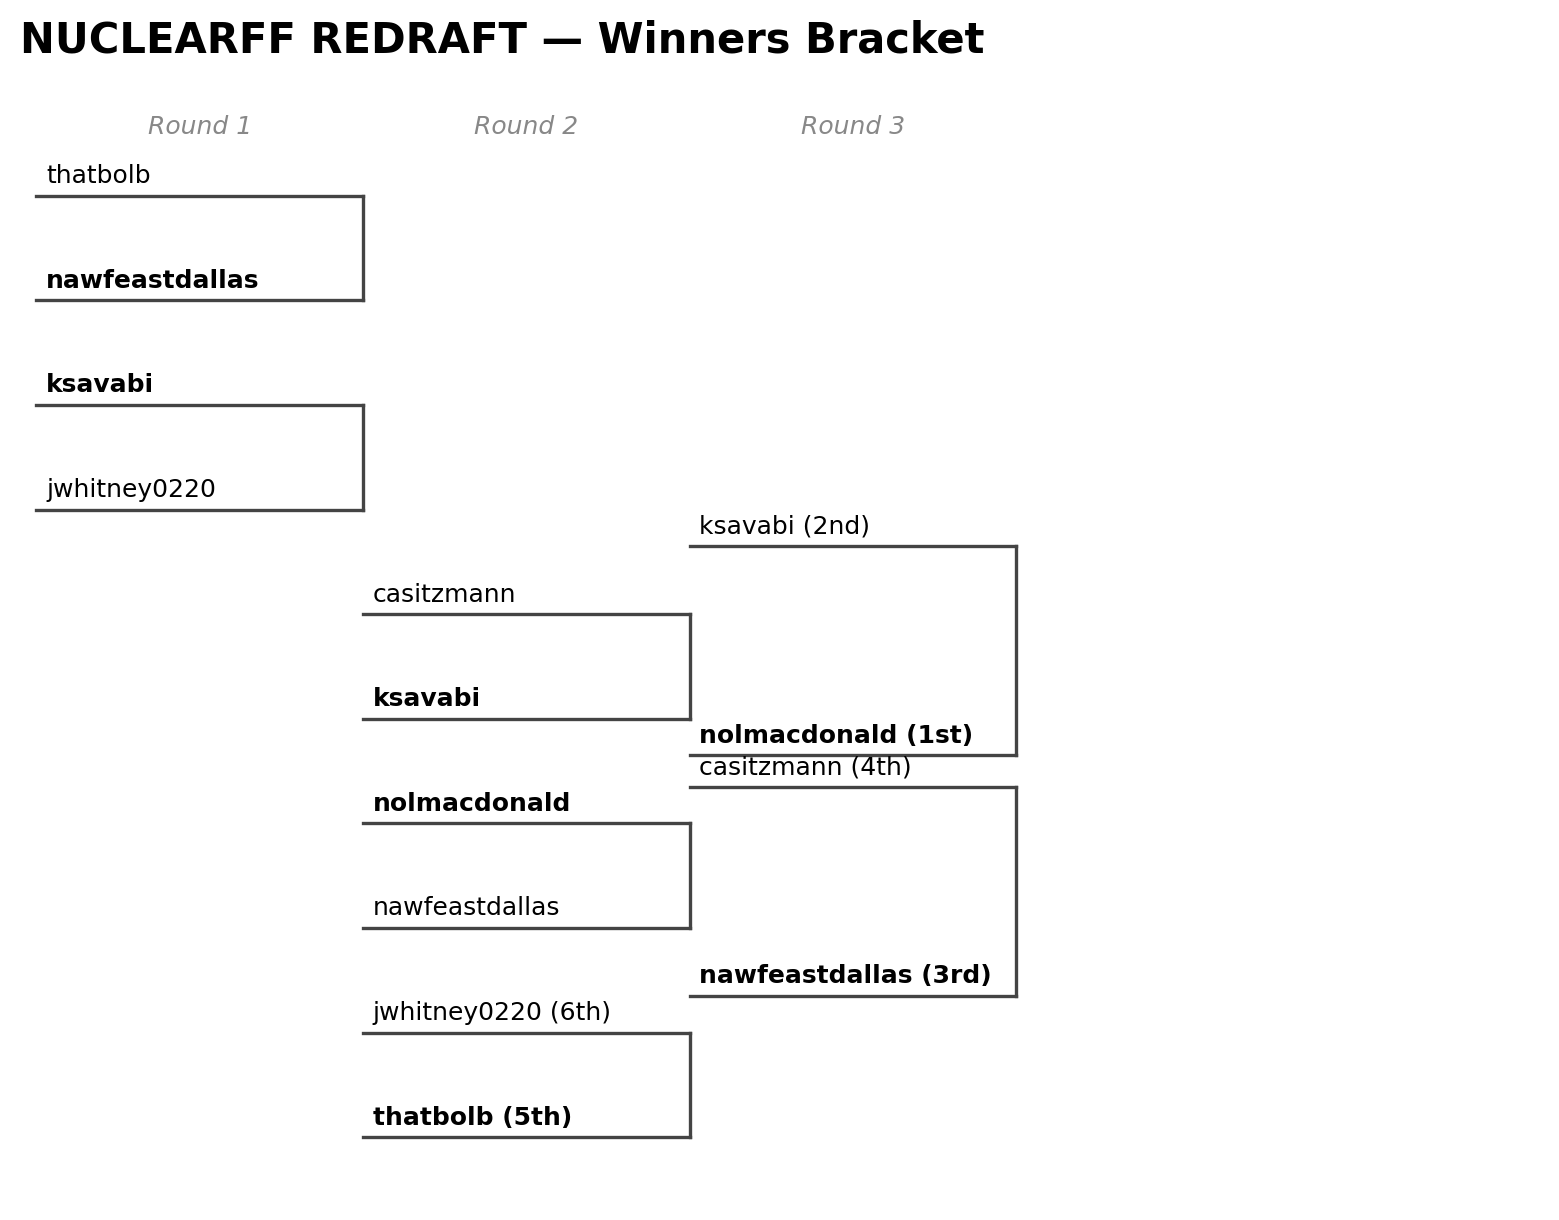

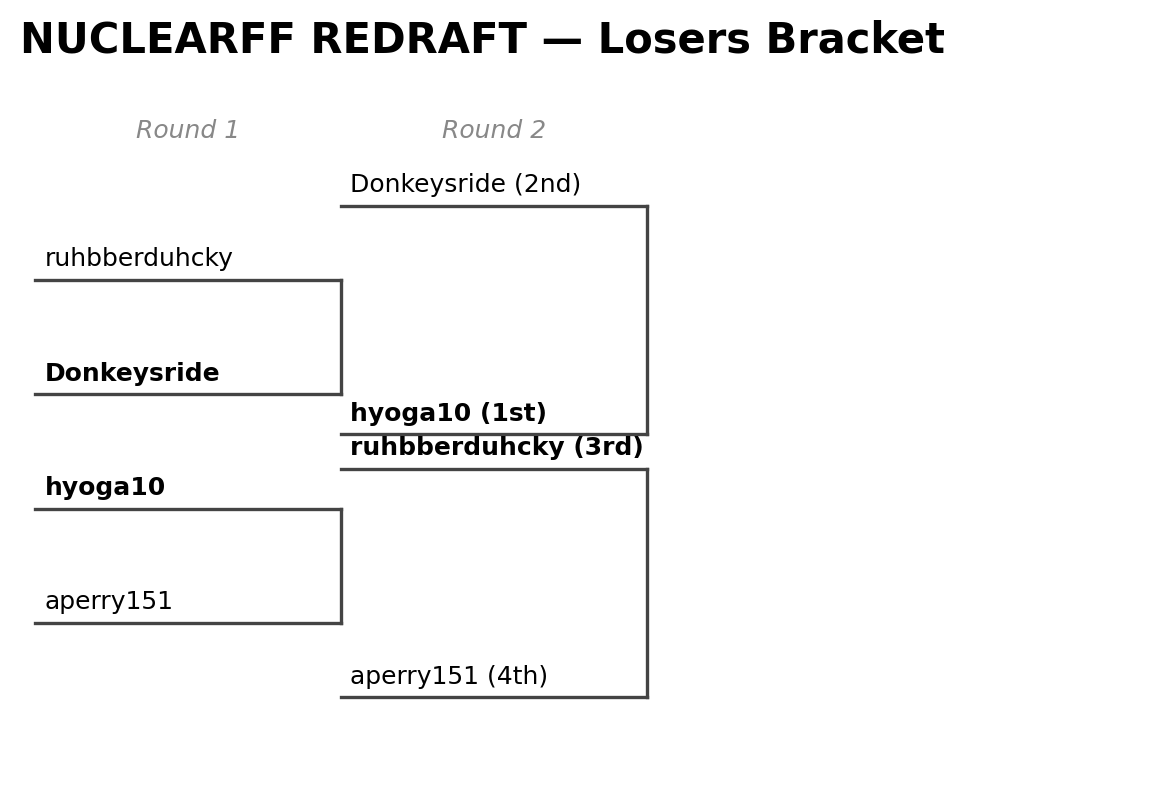

In [7]:
from IPython.display import Image, display

display(
    Image(
        filename="./demo/data/artifacts/1240509989819273216-2025/brackets/winners_bracket.png"
    )
)
display(
    Image(
        filename="./demo/data/artifacts/1240509989819273216-2025/brackets/losers_bracket.png"
    )
)

## Weekly matchups

`--matchups` fetches every week's roster-vs-roster scoring, for every season in the chain. `--max-week` caps how many weeks per season (default 18); weeks that haven't happened yet return no data and are silently skipped, not an error.

In [8]:
!uv run nuclearff --root ./demo sleeper fetch-league --league-id 1367225133634191360 --matchups --max-week 3

2026-09-09T23:17:29 [INFO] nuclearff.sleeper.matchups: Wrote 180 Sleeper matchup row(s) to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/cache/nuclearff.duckdb


2026-09-09T23:17:29 [INFO] nuclearff.sleeper.snapshot: Wrote Sleeper snapshot to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/raw/sleeper/1367225133634191360/20260910T061726Z
League:   NUCLEARFF REDRAFT (1367225133634191360)
Season:   2026 status=in_season
Teams:    10
Snapshot: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/raw/sleeper/1367225133634191360/20260910T061726Z
League config: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/configs/leagues/1367225133634191360.yaml

Settings to review:
  [WARNING] draft_rounds_mismatch: League settings report draft_rounds=3 but the draft object reports rounds=15.
           -> Trust the draft object. The league field is stale; use 15 rounds for pick-gap and VONA math.
  [WARNING] keepers_in_redraft: League type is 0 (redraft) but max_keepers=1.
           -> Treat the league as redraft, but confirm in the Sleeper UI whether a keeper is actually in play.
  [INFO] median_scoring: Each team also pla

## Transaction history

`--transactions` fetches every week's adds, drops, waivers, and trades, across the full history chain. Sleeper's own `type`/`status` fields are trusted and stored as-is, not re-derived -- a full-history fetch against this league surfaced four distinct transaction types (`waiver`, `free_agent`, `trade`, and a `commissioner` type not seen in a smaller single-season sample), all handled with no code change needed.

In [9]:
!uv run nuclearff --root ./demo sleeper fetch-league --league-id 1367225133634191360 --transactions --max-week 3

2026-09-09T23:17:37 [INFO] nuclearff.sleeper.transactions: Wrote 352 transaction(s) and 527 transaction-player row(s) to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/cache/nuclearff.duckdb
2026-09-09T23:17:37 [INFO] nuclearff.sleeper.snapshot: Wrote Sleeper snapshot to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/raw/sleeper/1367225133634191360/20260910T061731Z
League:   NUCLEARFF REDRAFT (1367225133634191360)
Season:   2026 status=in_season
Teams:    10
Snapshot: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/raw/sleeper/1367225133634191360/20260910T061731Z
League config: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/configs/leagues/1367225133634191360.yaml

Settings to review:
  [WARNING] draft_rounds_mismatch: League settings report draft_rounds=3 but the draft object reports rounds=15.
           -> Trust the draft object. The league field is stale; use 15 rounds for pick-gap and VONA math.
  [WARNING] keepers_in_r

In [10]:
with duckdb.connect(DB, read_only=True) as conn:
    rows = conn.execute(
        "SELECT type, COUNT(*) FROM sleeper_transactions GROUP BY type"
    ).fetchall()
rows

[('free_agent', 102), ('waiver', 245), ('trade', 5)]

## Roster composition

`--roster-players` categorizes every roster's players by slot (`starter`, `reserve`/IR, `taxi`, `bench`), per season. Sleeper fills an empty starting slot with the literal string `"0"` before a draft; that filler is dropped rather than stored as a phantom player.

In [11]:
!uv run nuclearff --root ./demo sleeper fetch-league --league-id 1367225133634191360 --roster-players

2026-09-09T23:17:40 [INFO] nuclearff.sleeper.roster_players: Wrote 943 roster-player row(s) to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/cache/nuclearff.duckdb
2026-09-09T23:17:40 [INFO] nuclearff.sleeper.snapshot: Wrote Sleeper snapshot to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/raw/sleeper/1367225133634191360/20260910T061738Z
League:   NUCLEARFF REDRAFT (1367225133634191360)
Season:   2026 status=in_season
Teams:    10
Snapshot: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/raw/sleeper/1367225133634191360/20260910T061738Z
League config: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/configs/leagues/1367225133634191360.yaml

Settings to review:
  [WARNING] draft_rounds_mismatch: League settings report draft_rounds=3 but the draft object reports rounds=15.
           -> Trust the draft object. The league field is stale; use 15 rounds for pick-gap and VONA math.
  [WARNING] keepers_in_redraft: League type is 0 (

In [12]:
with duckdb.connect(DB, read_only=True) as conn:
    rows = conn.execute(
        "SELECT slot, COUNT(*) FROM sleeper_roster_players GROUP BY slot"
    ).fetchall()
rows

[('starter', 540), ('bench', 358), ('reserve', 45)]

## Combining flags

Every flag above implies `--history` and is independent of the others -- combine as many as you want in one run; each writes its own table(s) without disturbing the rest. Every write replaces its table wholesale, so a fresh run is a fresh full snapshot, not an incremental append.

In [13]:
!uv run nuclearff --root ./demo sleeper fetch-league --league-id 1367225133634191360 --history --standings --matchups --max-week 3

2026-09-09T23:17:43 [INFO] nuclearff.sleeper.leagues: Wrote 6 Sleeper league(s) (6 with a parsed config) to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/cache/nuclearff.duckdb


2026-09-09T23:17:47 [INFO] nuclearff.sleeper.standings: Wrote 60 standings row(s) and 66 playoff match row(s) to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/cache/nuclearff.duckdb


2026-09-09T23:17:49 [INFO] nuclearff.sleeper.matchups: Wrote 180 Sleeper matchup row(s) to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/cache/nuclearff.duckdb
2026-09-09T23:17:49 [INFO] nuclearff.sleeper.snapshot: Wrote Sleeper snapshot to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/raw/sleeper/1367225133634191360/20260910T061742Z
League:   NUCLEARFF REDRAFT (1367225133634191360)
Season:   2026 status=in_season
Teams:    10
Snapshot: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/raw/sleeper/1367225133634191360/20260910T061742Z
League config: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/configs/leagues/1367225133634191360.yaml

Settings to review:
  [WARNING] draft_rounds_mismatch: League settings report draft_rounds=3 but the draft object reports rounds=15.
           -> Trust the draft object. The league field is stale; use 15 rounds for pick-gap and VONA math.
  [WARNING] keepers_in_redraft: League type is 0 (redr

## Discovering leagues from a username

Every command above needs an already-known `league_id`. If you only have a Sleeper username, resolve it first -- this resolves the username to a `user_id` via `GET /v1/user/<username>`, the same resolution whether you pass a username or a raw numeric id.

In [14]:
!uv run nuclearff --root ./demo sleeper user-leagues nolmacdonald --season 2026

User:    nolmacdonald (332632476830679040)
Leagues: 18 for nfl 2026
  1397668648528650240  Antares Sunday Operations  status=in_season
  1389346819275771904  Backpack Boyz  status=in_season
  1387927955862200320  Sacks in the city  status=in_season
  1367225133634191360  NUCLEARFF REDRAFT  status=in_season
  1367169730632220672  NUCLEARFF CHOPPED $50  status=in_season
  1367168783709384704  NUCLEARFF CHOPPED $25  status=in_season
  1367168140898766848  NUCLEARFF CHOPPED OG $10  status=in_season
  1367167628489007104  NUCLEARFF CHOPPED $10 02  status=in_season
  1327454794725457920  Shadows SuperFlex Dynasty  status=in_season
  1313971202405986304  NATO  status=in_season
  1313346760332029952  NUCLEARFF DYNASTY  status=in_season
  1313324299263692800  AB’s Legion of CTE  status=in_season
  1312528581959614464  Kundis   status=in_season
  1312889074398294016  Dynasty Degenerates  status=in_season
  1313739523607265280  Dynasty Fish Bowl Tiger Barb Division  status=in_season
  13164738373

`sleeper user-drafts <username> --season <year>` works the same way for drafts instead of leagues.

## The player map, filtering, and trending

`fetch-players` pulls Sleeper's full NFL player map (roughly 5 MB) into a `sleeper_players` table -- the join target for every `player_id` column in this project. Cached to disk for 24 hours; `--force-refresh` bypasses that.

In [15]:
!uv run nuclearff --root ./demo sleeper fetch-players

2026-09-09T23:17:50 [INFO] nuclearff.sleeper.client: Fetching Sleeper player map (~5MB); this is cached for 24h


2026-09-09T23:17:58 [INFO] nuclearff.sleeper.players: Wrote 12227 Sleeper players to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/cache/nuclearff.duckdb (table sleeper_players)


Players:  12227
Database: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/cache/nuclearff.duckdb


If you only need part of the map, filter server-side instead of fetching everything -- confirmed live, this cuts the payload from roughly 14.6 MB to 435 KB.

In [16]:
from nuclearff.sleeper import SleeperClient

with SleeperClient() as client:
    active_qbs = client.get_players(position="QB", active=True)

len(active_qbs)

355

`sleeper trending` shows the most-added/dropped players league-wide right now, resolved to real names when a local player table exists. Team defenses (e.g. a real result like "Las Vegas Raiders") resolve through a first/last-name fallback -- Sleeper's real payload gives a defense entry no `full_name` field, only split `first_name`/`last_name`.

In [17]:
!uv run nuclearff --root ./demo sleeper trending --limit 5

Trending add (last 24h):
  Michael Mayer                count=1497429
  Roschon Johnson              count=207600
  Darren Waller                count=180306
  Devaughn Vele                count=176316
  Las Vegas Raiders            count=166890


## Cross-referencing to nflverse

Sleeper player objects already carry `gsis_id` -- nflverse's own primary key -- but not every player has one. `ids resolve-gsis` fills the gap from nflverse's own ID crosswalk, skipping any `sleeper_id` that maps to more than one player rather than guessing. Requires `fetch-players` to have run first.

In [18]:
!uv run nuclearff --root ./demo ids resolve-gsis

2026-09-09T23:18:00 [INFO] nuclearff.nflverse.loader: Fetching nflverse ff_playerids crosswalk


Players:                   12227
gsis_id from Sleeper:      3893
gsis_id from ff_playerids: 3522
Still unresolved:          4812

Skipped 6 ambiguous crosswalk sleeper_id value(s) (maps to more than one player; not used to fill gaps).


## Auction/keeper draft valuation

If your league runs (or ran) an auction draft, `report auction-board` turns realized fantasy points into a priced draft board -- recency-weighted realized points, per-position replacement level and VORP, FantasyPros consensus join, dollars that sum to exactly the league's real budget. `NUCLEARFF REDRAFT` (this notebook's running example everywhere else) runs a snake draft, so it isn't usable for this particular command -- `Freeman Forever League` below is a different real league on the same account whose `draft.type` is `"auction"`.

In [19]:
!uv run nuclearff --root ./demo report auction-board 1387966835797798912 --seasons 2024 2025 --as-of-season 2026

2026-09-09T23:18:06 [INFO] nuclearff.pipeline.auction_board: Building auction board for 'Freeman Forever League' (2026): 10 teams, $200 each, 14 roster spots


2026-09-09T23:18:06 [INFO] nuclearff.nflverse.stats: Fetching nflverse seasonal player stats for seasons [2024, 2025]


2026-09-09T23:18:06 [WARNING] nuclearff.scoring.engine: ScoringEngine has no mapping for 27 nonzero scoring key(s); these will not be counted toward fantasy points: blk_kick=2.0, def_pass_def=0.10000000149011612, def_st_fum_rec=2.0, def_st_td=6.0, def_td=6.0, fgm_0_19=3.0, fgm_20_29=3.0, fgm_30_39=3.0, fgm_40_49=3.0, fgm_50p=3.0, fgm_yds_over_30=0.10000000149011612, fgmiss=-1.0, fum_rec=2.0, fum_rec_td=6.0, int=2.0, pts_allow_0=9.0, pts_allow_1_6=6.0, pts_allow_21_27=-1.0, pts_allow_28_34=-2.0, pts_allow_35p=-5.0, pts_allow_7_13=3.0, sack=1.0, safe=2.0, st_td=6.0, tkl_loss=0.25, xpm=1.0, xpmiss=-1.0
2026-09-09T23:18:06 [INFO] nuclearff.pipeline.auction_board: Scoring engine ignored 27 league scoring key(s) with no nflverse stat mapping (kicker/defense/IDP keys are expected here): ['blk_kick', 'def_pass_def', 'def_st_fum_rec', 'def_st_td', 'def_td', 'fgm_0_19', 'fgm_20_29', 'fgm_30_39', 'fgm_40_49', 'fgm_50p']


2026-09-09T23:18:06 [INFO] nuclearff.pipeline.auction_board: Replacement level (QB, vols): rank 10 -> 306.6 points
2026-09-09T23:18:06 [INFO] nuclearff.pipeline.auction_board: Replacement level (RB, vols): rank 27 -> 160.0 points
2026-09-09T23:18:06 [INFO] nuclearff.pipeline.auction_board: Replacement level (WR, vols): rank 30 -> 146.6 points
2026-09-09T23:18:06 [INFO] nuclearff.pipeline.auction_board: Replacement level (TE, vols): rank 13 -> 120.0 points
2026-09-09T23:18:06 [INFO] nuclearff.nflverse.rankings: Fetching FantasyPros ECR (nflreadpy load_ff_rankings type='draft', page_type='redraft-overall')


2026-09-09T23:18:07 [INFO] nuclearff.nflverse.loader: Fetching nflverse ff_playerids crosswalk
2026-09-09T23:18:07 [INFO] nuclearff.nflverse.rankings: attach_player_ids: resolved gsis_id for 478 of 525 ranking rows (91.0%)
2026-09-09T23:18:07 [INFO] nuclearff.report.build: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1387966835797798912-2026/auction_board.csv (746 rows)


2026-09-09T23:18:09 [INFO] nuclearff.report.tables: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1387966835797798912-2026/tables/top_12_qb.png (12 QB rows)


2026-09-09T23:18:09 [INFO] nuclearff.report.tables: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1387966835797798912-2026/tables/top_12_rb.png (12 RB rows)


2026-09-09T23:18:10 [INFO] nuclearff.report.tables: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1387966835797798912-2026/tables/top_12_wr.png (12 WR rows)


2026-09-09T23:18:10 [INFO] nuclearff.report.tables: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1387966835797798912-2026/tables/top_12_te.png (12 TE rows)
2026-09-09T23:18:10 [INFO] nuclearff.report.build: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1387966835797798912-2026/report.md
League:          Freeman Forever League (2026)
Budget:          $200/team x 10 teams
Players valued:  746
In draft pool:   140
Report:          /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1387966835797798912-2026/report.md


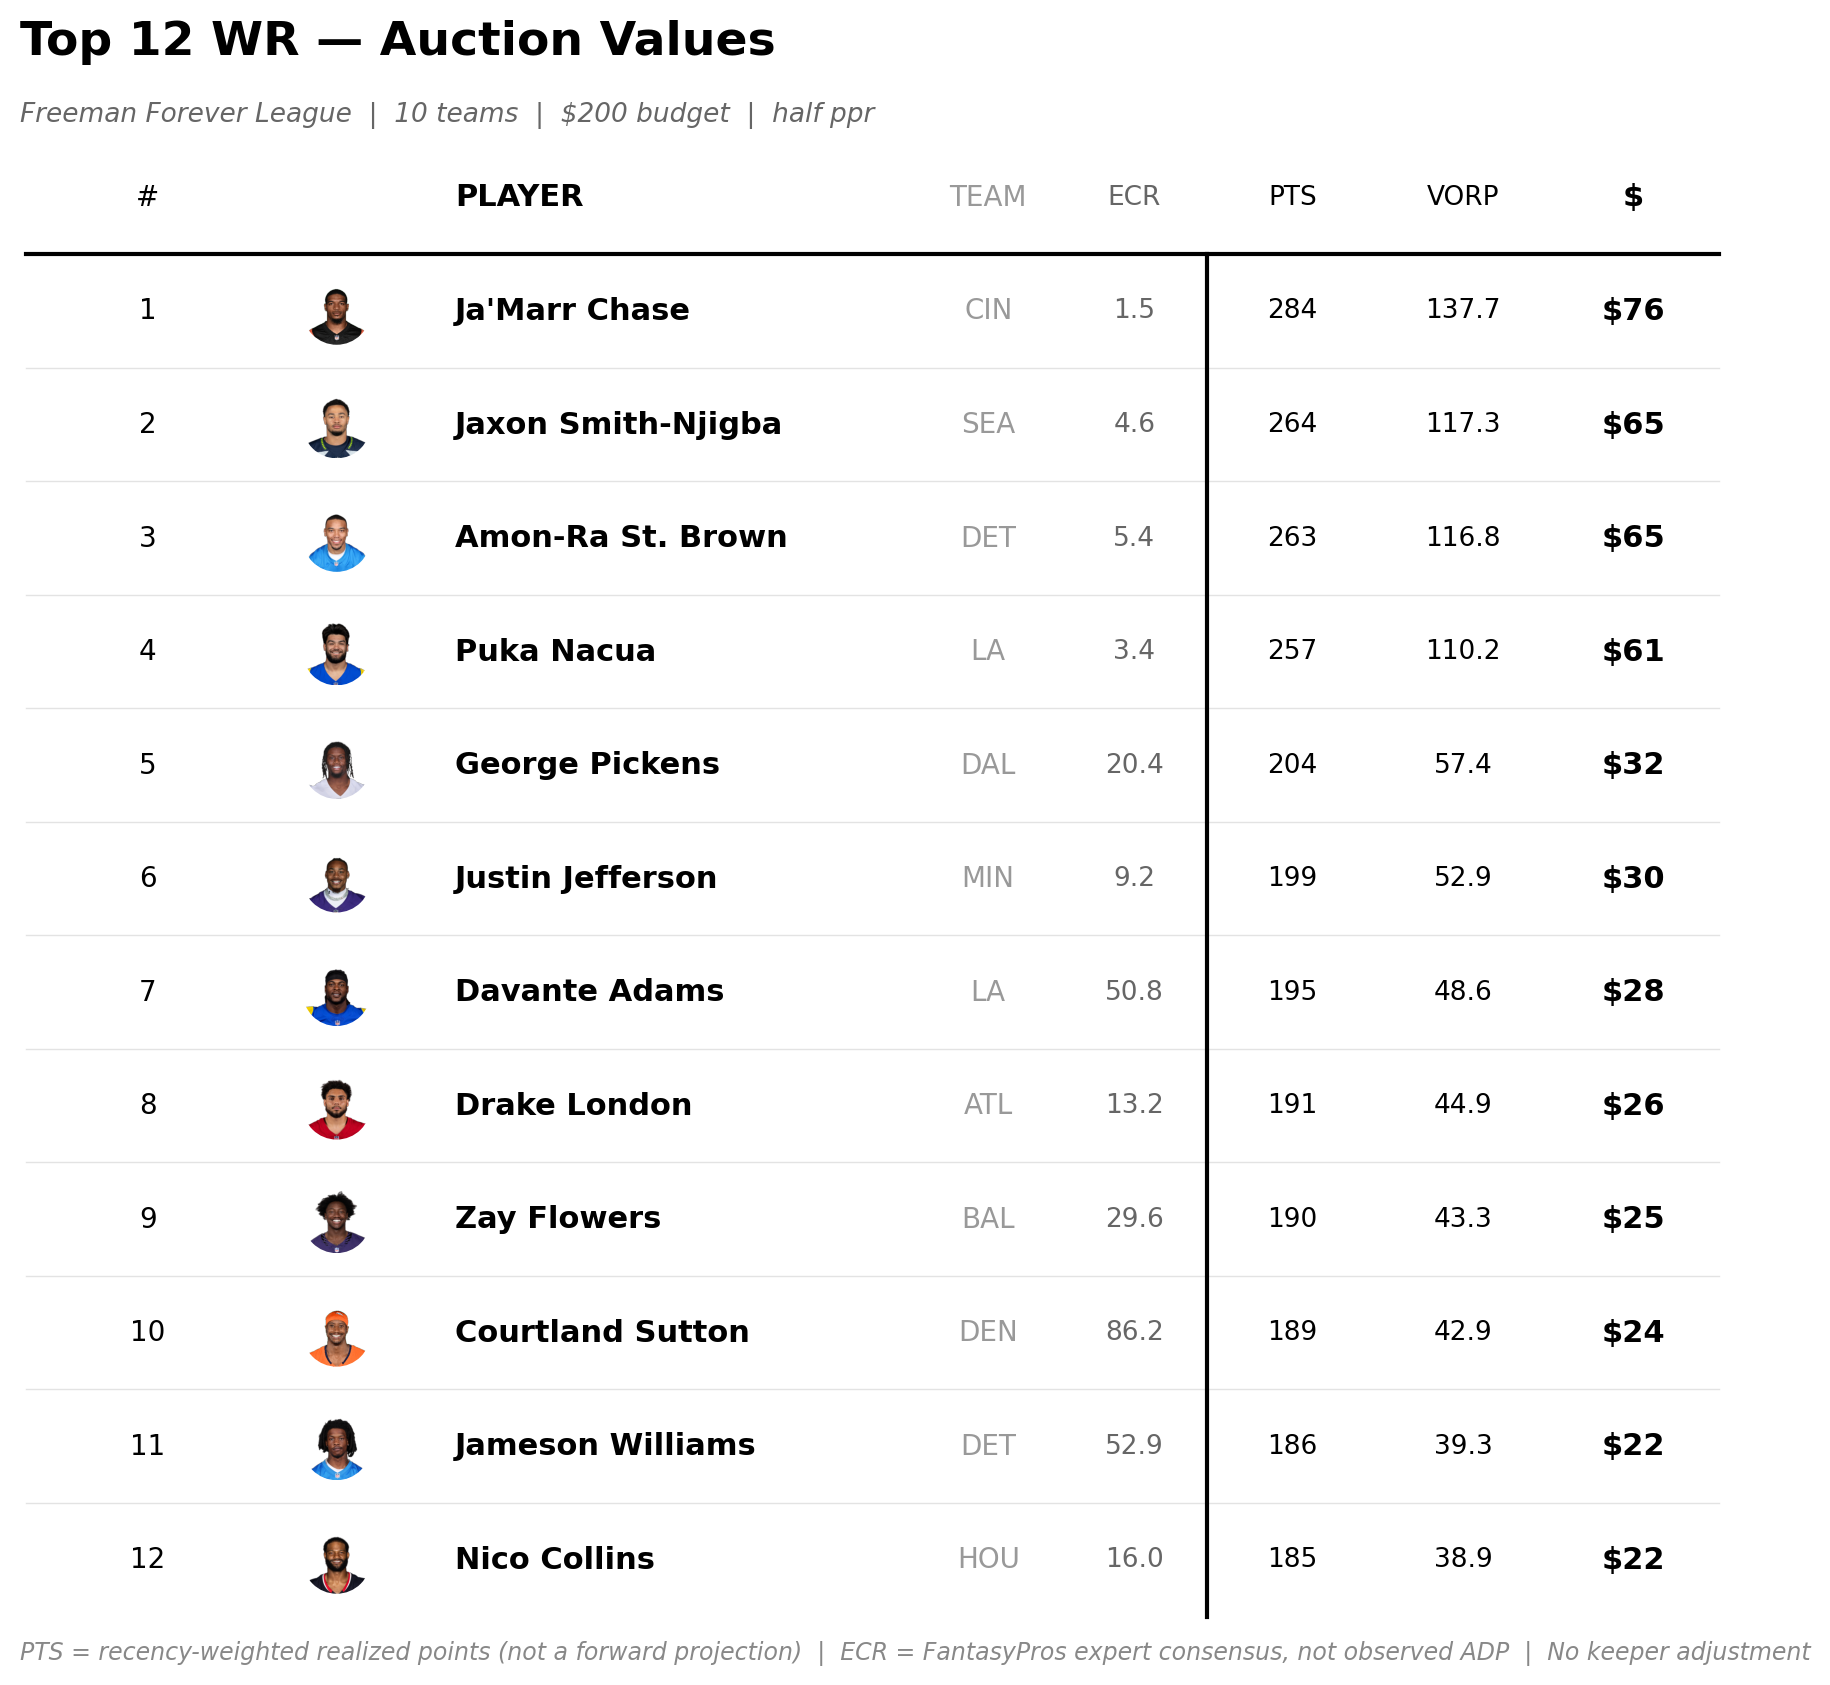

In [20]:
from IPython.display import Image, display

display(
    Image(
        filename="./demo/data/artifacts/1387966835797798912-2026/tables/top_12_wr.png"
    )
)

Output is a CSV, a markdown report with methodology notes, and (unless `--no-tables`) a styled PNG table per position (QB/RB/WR/TE) -- the WR table is shown above as an example. Keeper cost adjustment is implemented but not yet wired into this command -- Sleeper exposes no keeper-price endpoint, so keeper costs must be supplied by the caller.

## Draft board visualization

`report draft-board` renders a draft as a snake-order grid of position-colored pick cards, matching Sleeper's own draft-room UI: one column per draft slot, one row per round. Cell color follows position (green RB, blue WR, pink QB, orange TE), confirmed against Sleeper's own draft-room UI. A draft's pick order isn't always a simple alternating snake -- this league's own draft has `settings.reversal_round: 3`; the grid doesn't compute pick order itself, each pick's own `draft_slot` is already resolved correctly by Sleeper, reversal round included.

In [21]:
!uv run nuclearff --root ./demo report draft-board 1367225133634191360

2026-09-09T23:18:11 [INFO] nuclearff.sleeper.draft: Wrote 150 draft pick row(s) to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/cache/nuclearff.duckdb


2026-09-09T23:18:12 [INFO] nuclearff.report.draft_board: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1367225133634191360-draft-board/1367225133646778368.png (150 picks)
Picks:       150
Draft board: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1367225133634191360-draft-board/1367225133646778368.png


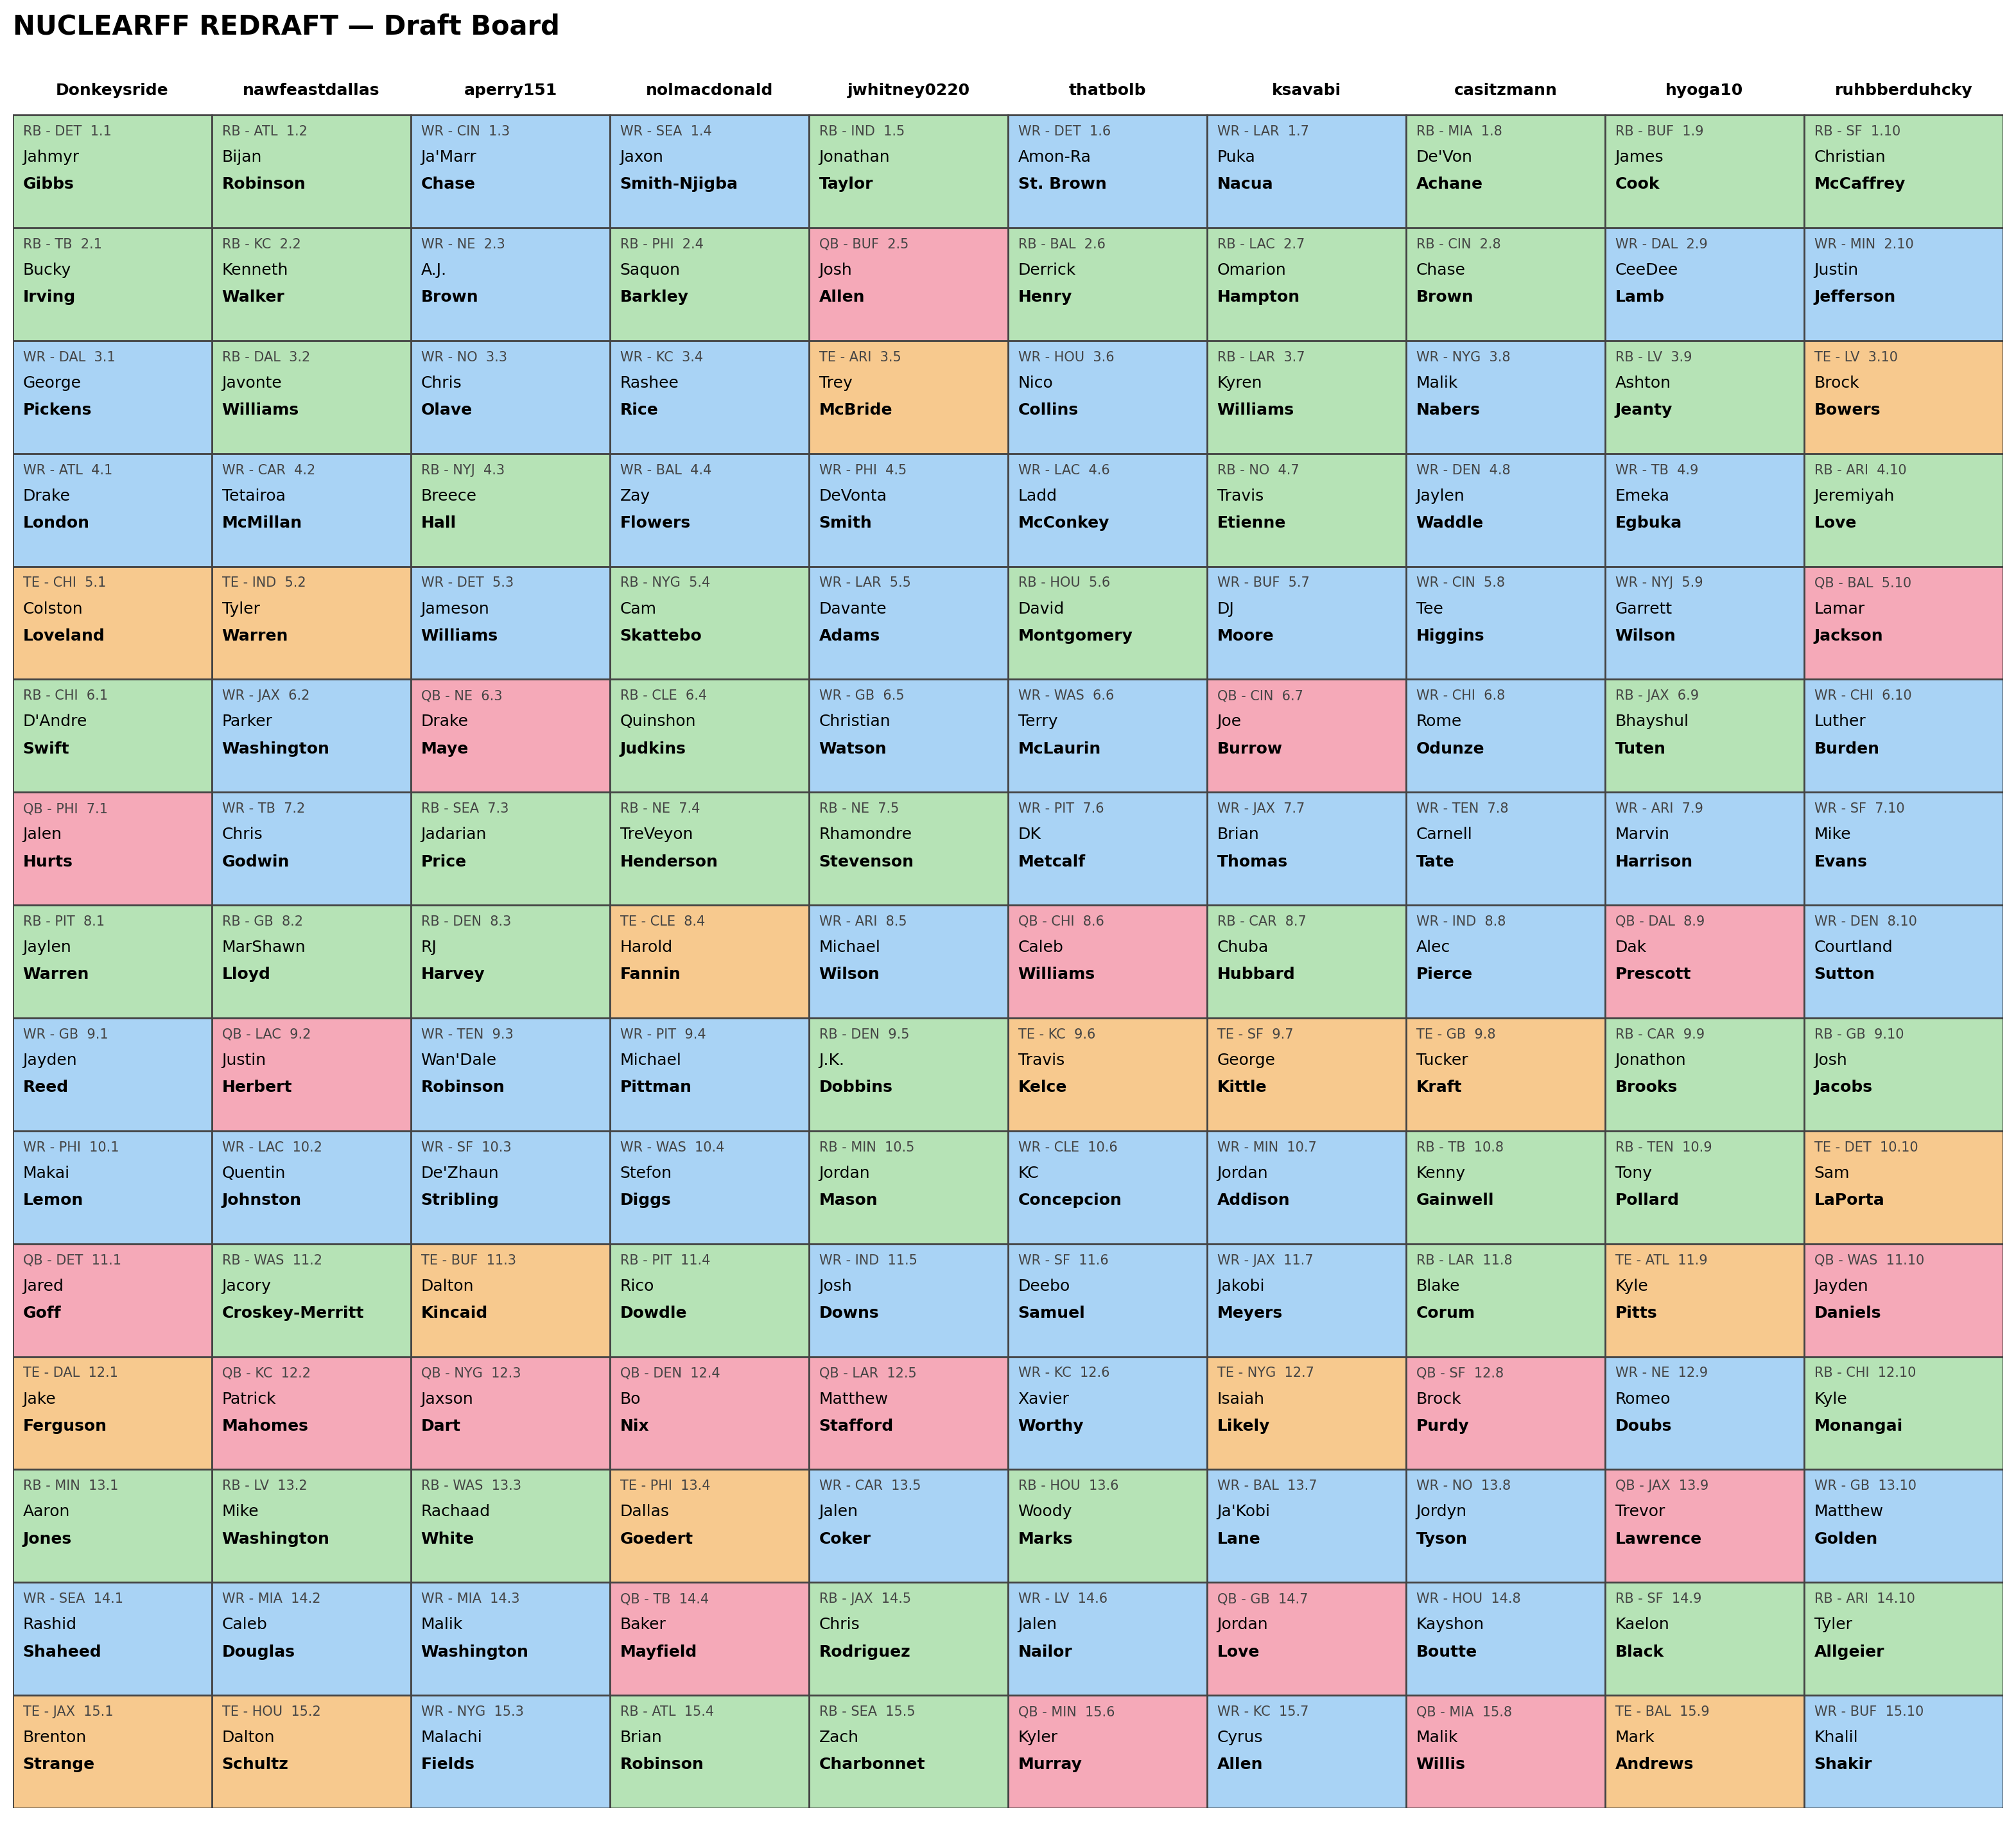

In [22]:
import glob

from IPython.display import Image, display

display(
    Image(
        filename=glob.glob(
            "./demo/data/artifacts/1367225133634191360-draft-board/*.png"
        )[0]
    )
)

## League avatar table

`report user-leagues` resolves a username (or user id) to every league they're in for a season and renders it as a PNG table -- avatar, name, league id, type, team count, status -- with a per-type count summary at the bottom. `Type` resolves Sleeper's numeric `settings.type` (0/1/2/3) to a readable label, not a name-substring match.

In [23]:
!uv run nuclearff --root ./demo report user-leagues nolmacdonald --season 2026

2026-09-09T23:18:19 [INFO] nuclearff.report.user_leagues: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/332632476830679040-leagues/2026.png (18 leagues)
User:    nolmacdonald (332632476830679040)
Leagues: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/332632476830679040-leagues/2026.png


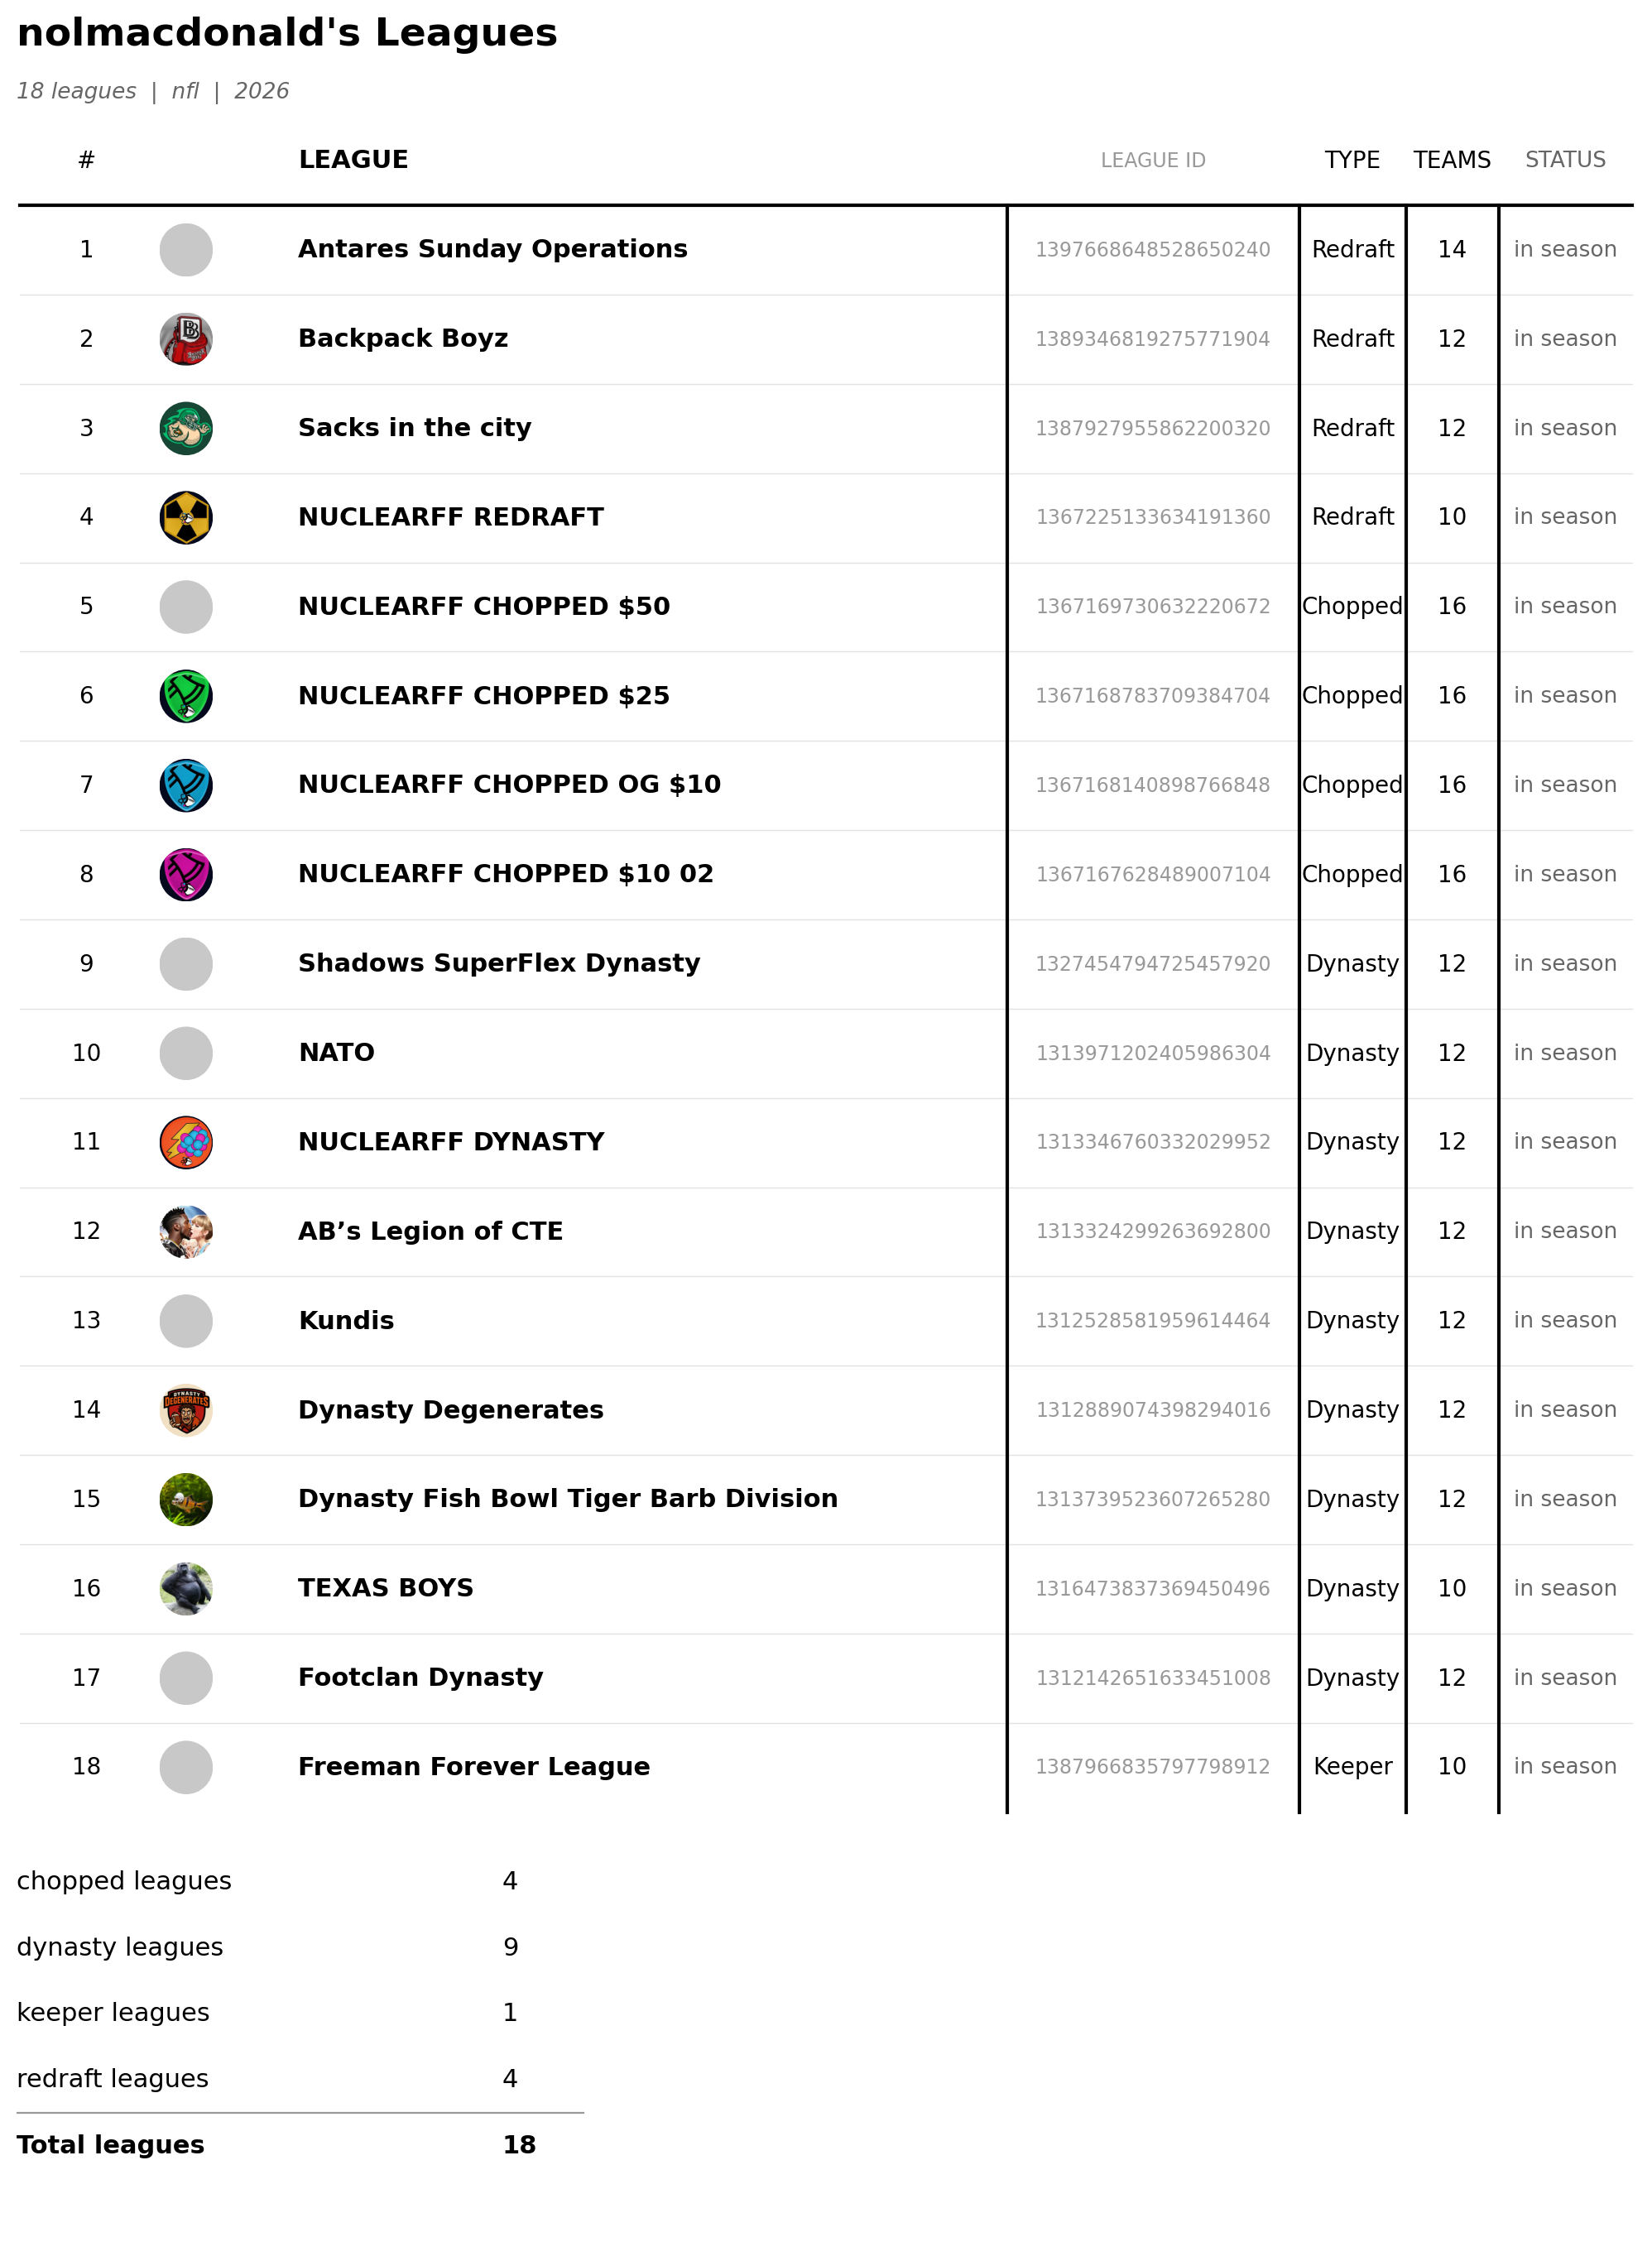

In [24]:
from IPython.display import Image, display

display(Image(filename="./demo/data/artifacts/332632476830679040-leagues/2026.png"))

## Cumulative wins

`report wins` derives a per-week win/loss/tie from stored matchup history (nothing stores this directly -- it's computed by comparing the two rosters sharing a matchup) and renders each manager's running win total as a step chart, one line per manager, ending in that manager's real Sleeper headshot instead of a text label.

By default, only managers currently rostered in `league_id`'s own season appear. `--all-users` includes every manager across the league's full history instead -- passed below since this is a historical walkthrough.

In [25]:
!uv run nuclearff --root ./demo report wins 1367225133634191360 --all-users

2026-09-09T23:18:27 [INFO] nuclearff.report.wins: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1367225133634191360-wins.png (15 managers)
Managers: 15
Wins:     /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1367225133634191360-wins.png


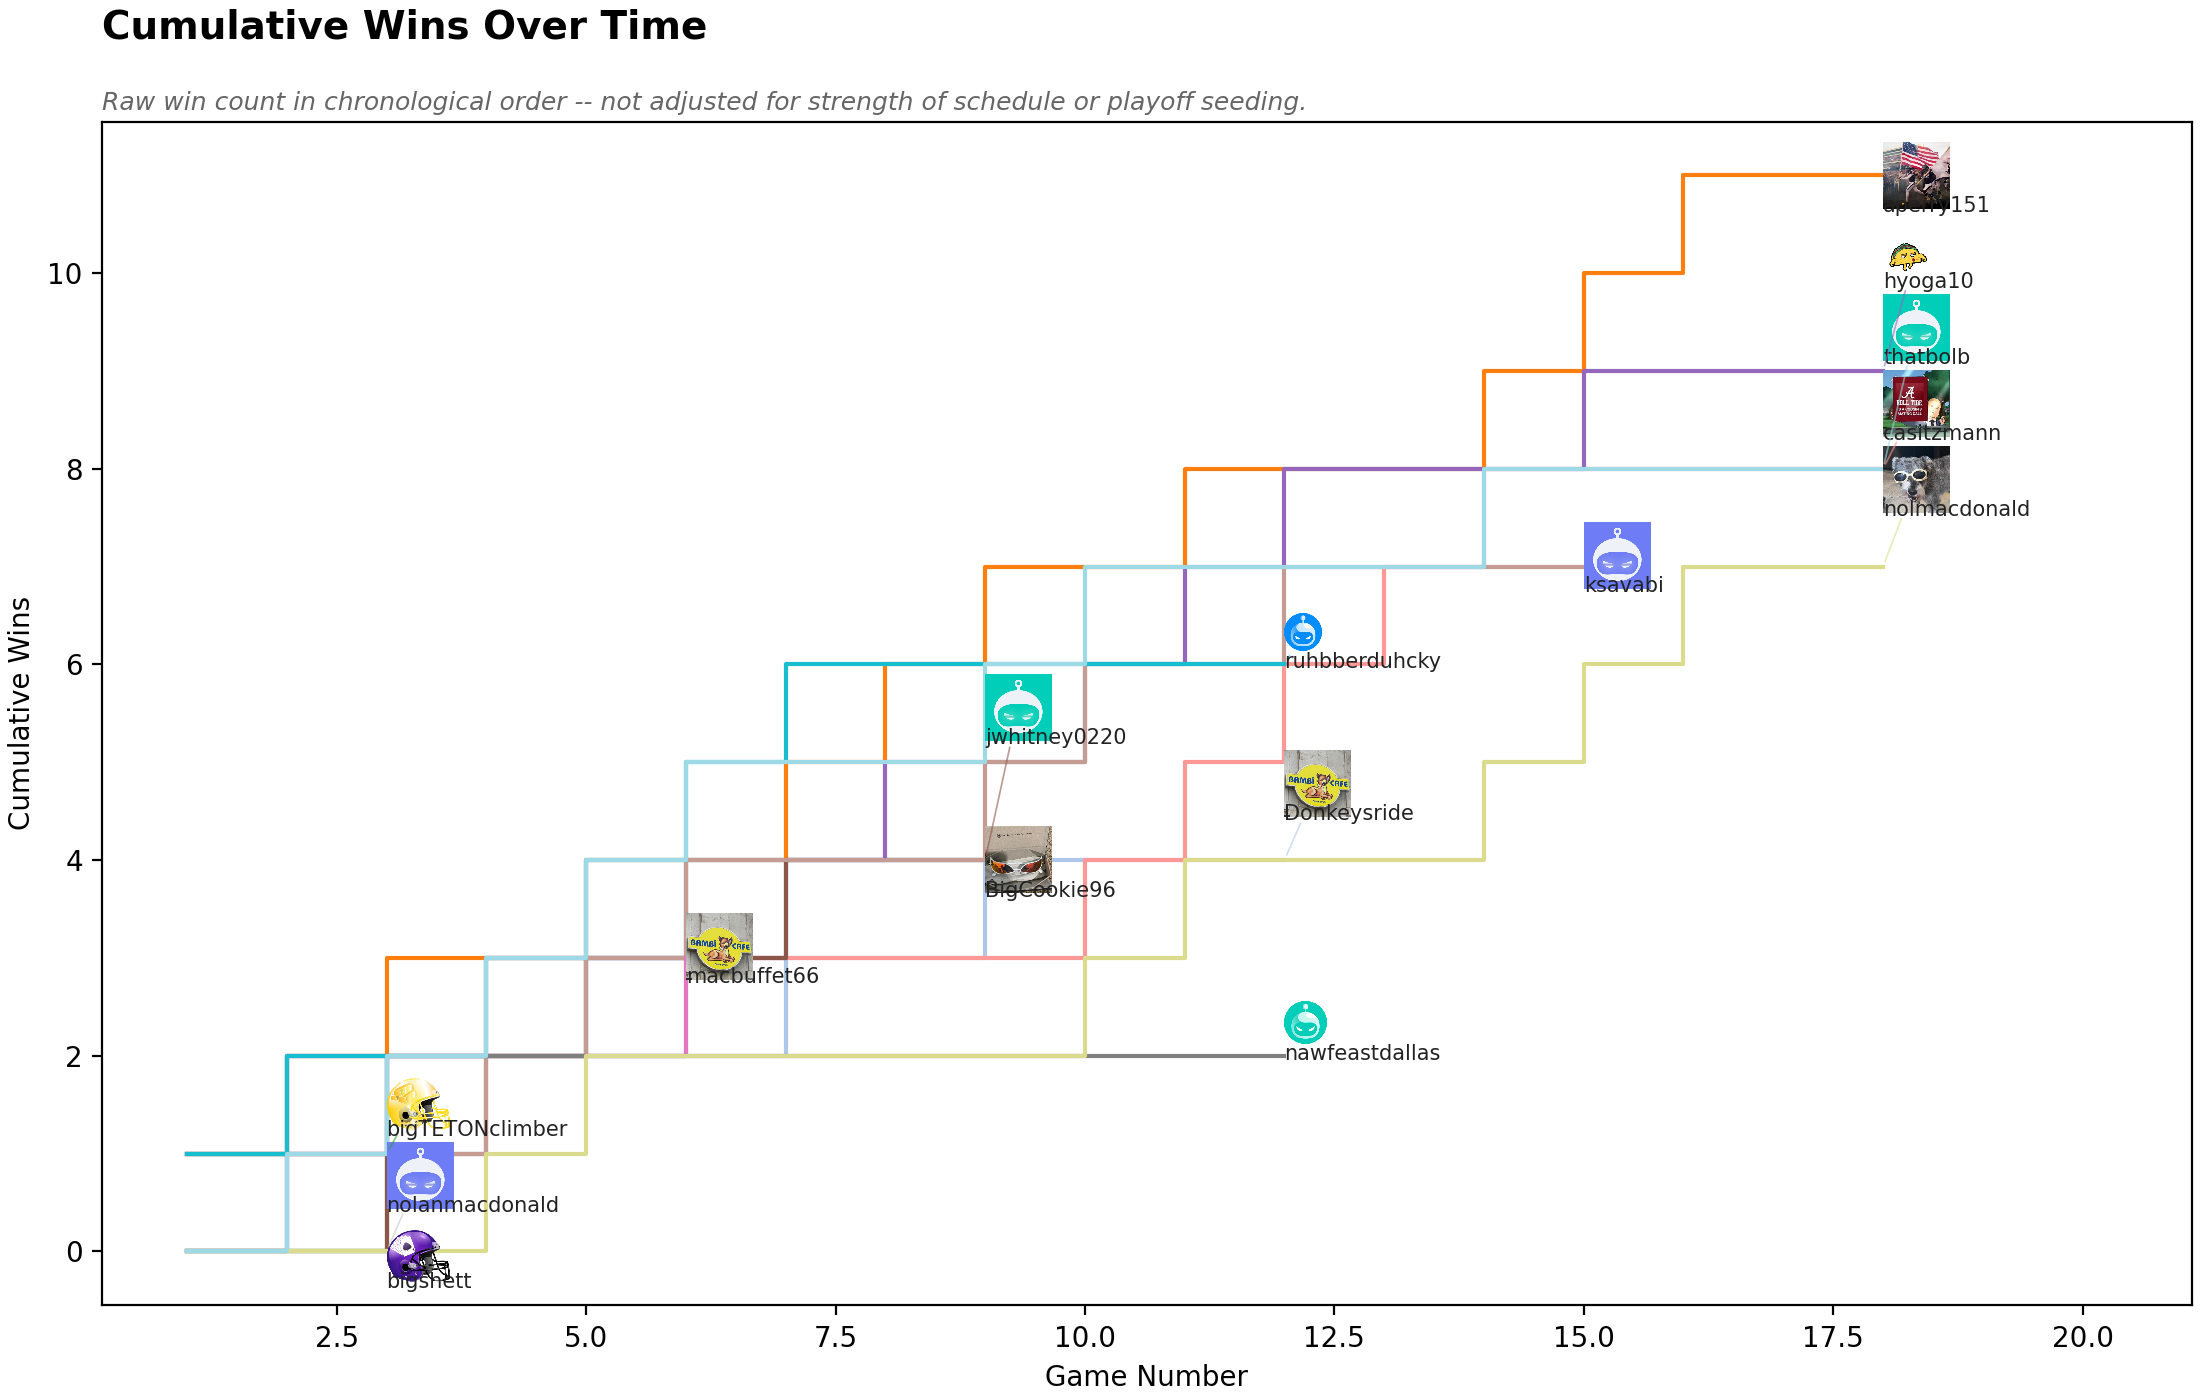

In [26]:
from IPython.display import Image, display

display(Image(filename="./demo/data/artifacts/1367225133634191360-wins.png"))

## Draft order history

`report draft-order` (needs `--drafts` fetched first, below) renders a manager's historical draft-order table: seasons drafted, average draft position, times drafted 1st overall, times drafted last. "Last pick" is season-relative -- a season's own real maximum draft slot, since team count can vary by season.

In [27]:
!uv run nuclearff --root ./demo sleeper fetch-league --league-id 1367225133634191360 --drafts

2026-09-09T23:18:33 [INFO] nuclearff.sleeper.draft: Wrote 900 draft pick row(s) across 6 league(s) to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/cache/nuclearff.duckdb


2026-09-09T23:18:33 [INFO] nuclearff.sleeper.snapshot: Wrote Sleeper snapshot to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/raw/sleeper/1367225133634191360/20260910T061829Z
League:   NUCLEARFF REDRAFT (1367225133634191360)
Season:   2026 status=in_season
Teams:    10
Snapshot: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/raw/sleeper/1367225133634191360/20260910T061829Z
League config: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/configs/leagues/1367225133634191360.yaml

Settings to review:
  [WARNING] draft_rounds_mismatch: League settings report draft_rounds=3 but the draft object reports rounds=15.
           -> Trust the draft object. The league field is stale; use 15 rounds for pick-gap and VONA math.
  [WARNING] keepers_in_redraft: League type is 0 (redraft) but max_keepers=1.
           -> Treat the league as redraft, but confirm in the Sleeper UI whether a keeper is actually in play.
  [INFO] median_scoring: Each team also pla

In [28]:
!uv run nuclearff --root ./demo report draft-order 1367225133634191360 --all-users

2026-09-09T23:18:34 [INFO] nuclearff.report.draft: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1367225133634191360-draft-order.png (15 managers)
Managers:    15
Draft order: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1367225133634191360-draft-order.png


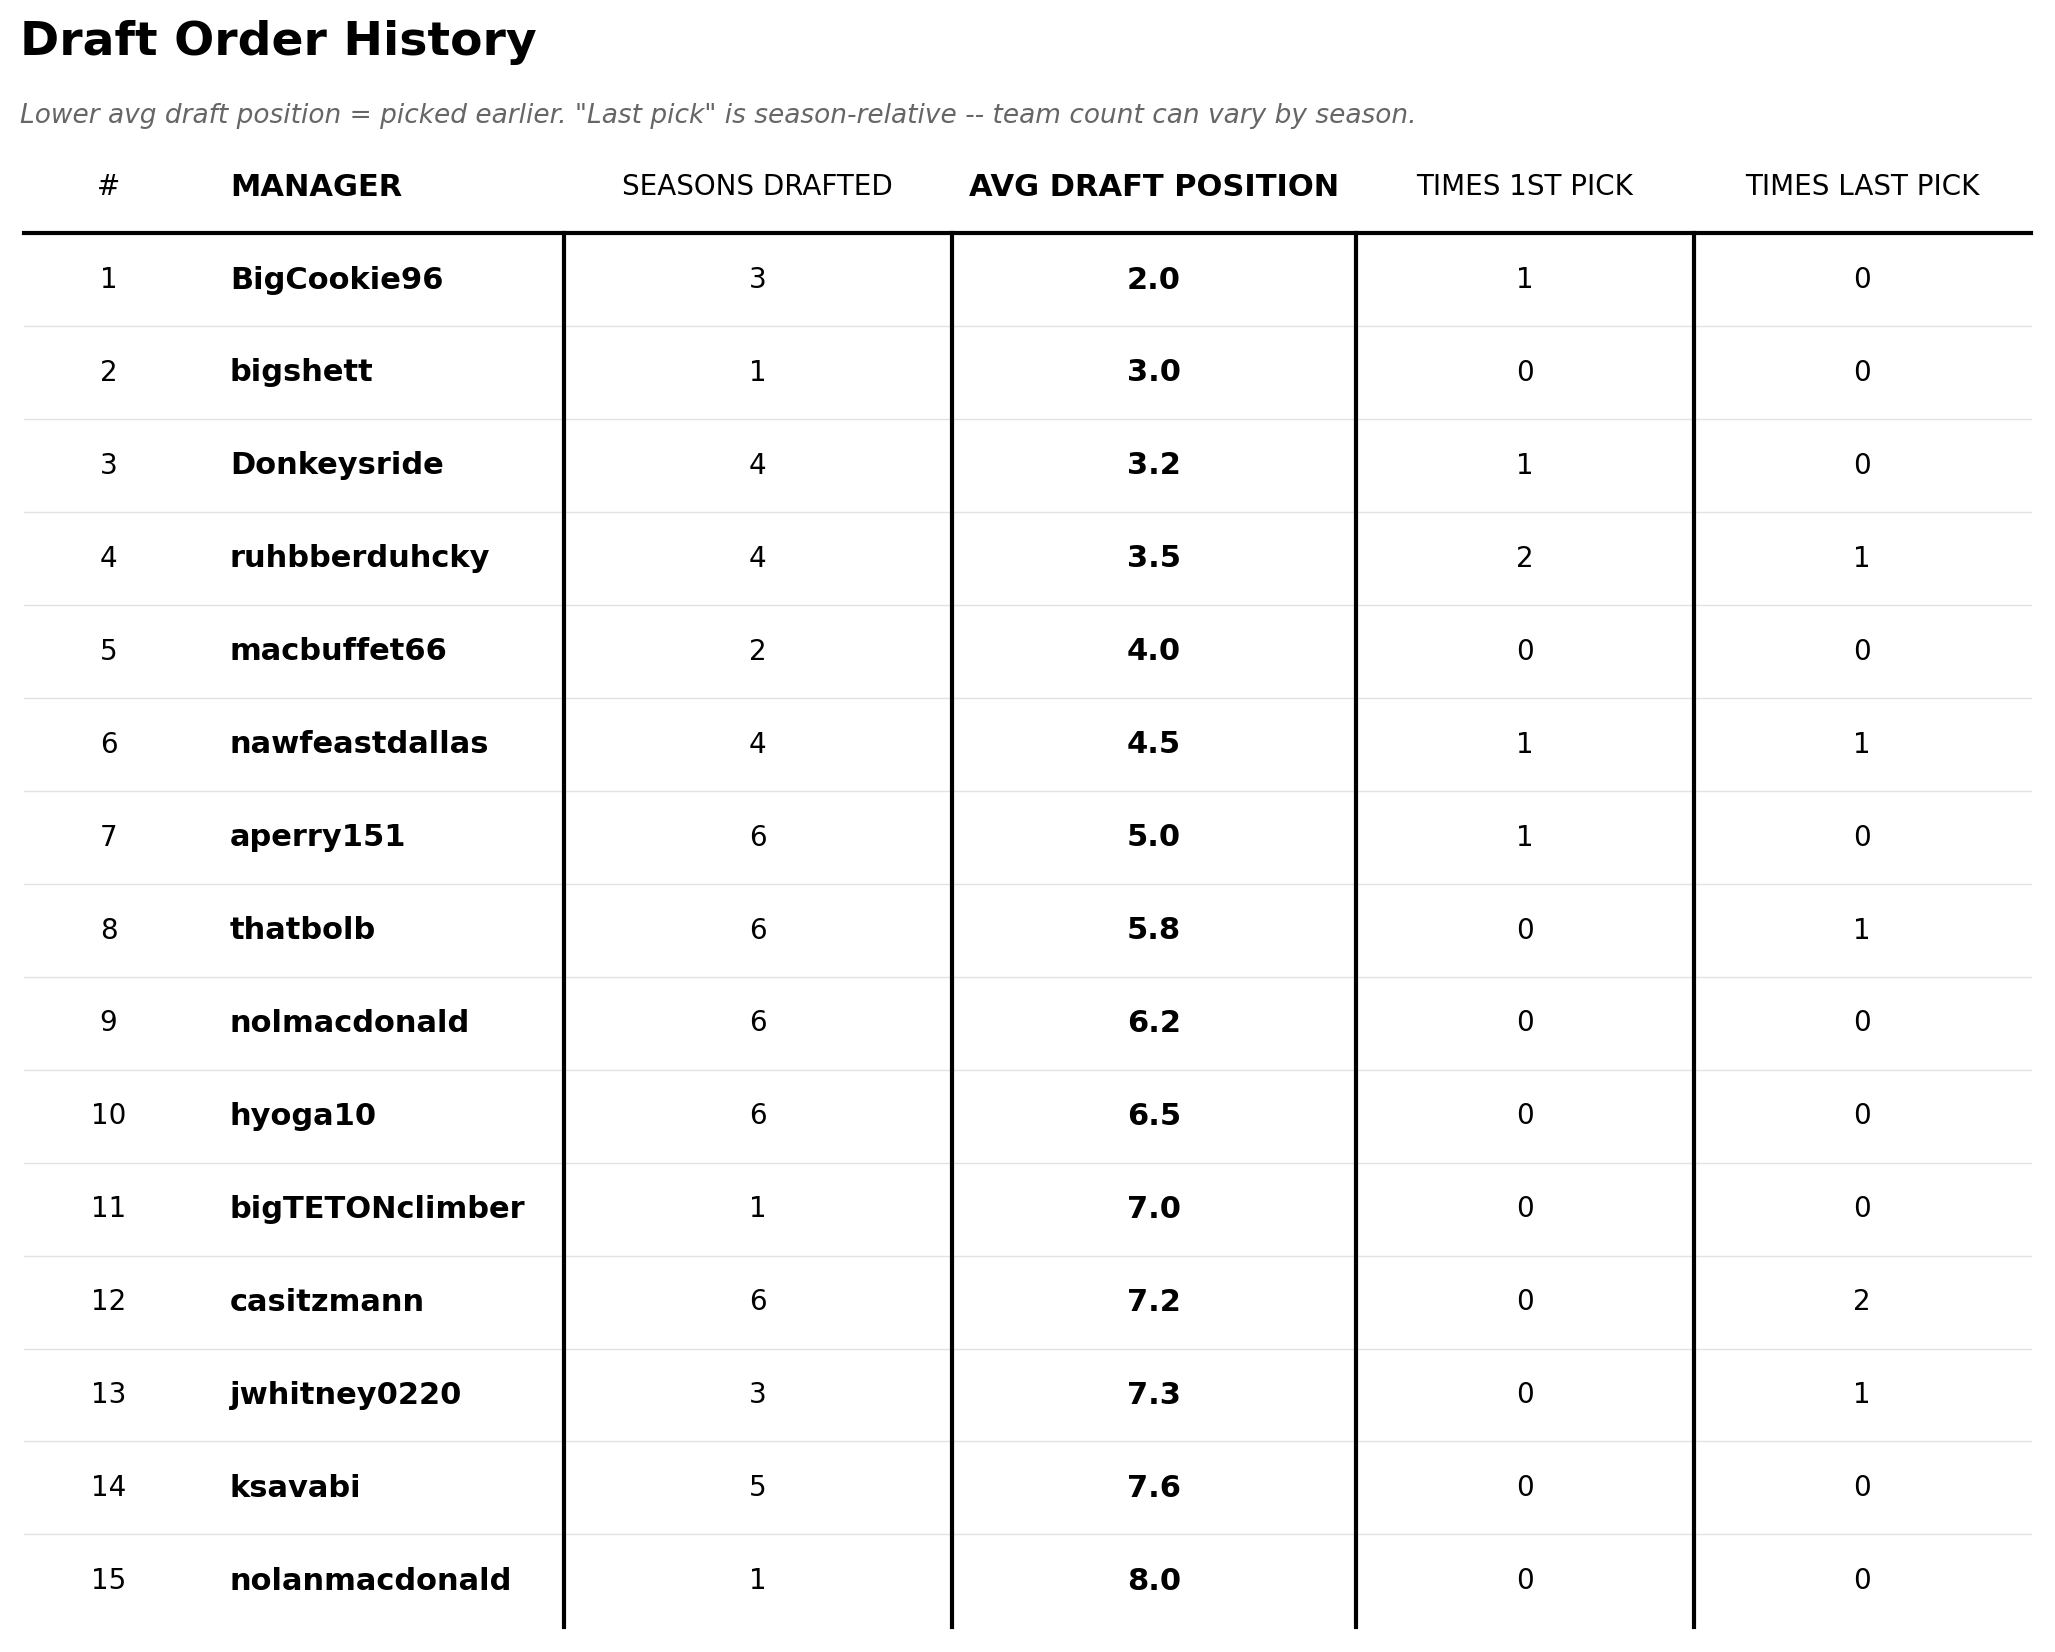

In [29]:
from IPython.display import Image, display

display(Image(filename="./demo/data/artifacts/1367225133634191360-draft-order.png"))

## Trade network analysis

`report trades` turns a league's stored trade history into ten PNGs -- who trades, who trades with whom, and how that's changed over time. It's its own notebook: `02_league_trade_history.ipynb`.

## Querying what you've built

Every table above lives in one DuckDB file. Query it directly with the `duckdb` CLI, or from Python:

In [30]:
with duckdb.connect(DB, read_only=True) as conn:
    conn.sql("SHOW TABLES").show()

┌─────────────────────────────┐
│            name             │
│           varchar           │
├─────────────────────────────┤
│ player_id_map               │
│ sleeper_draft_picks         │
│ sleeper_league_configs      │
│ sleeper_leagues             │
│ sleeper_matchups            │
│ sleeper_players             │
│ sleeper_playoff_matches     │
│ sleeper_roster_players      │
│ sleeper_standings           │
│ sleeper_transaction_players │
│ sleeper_transactions        │
└─────────────────────────────┘
            11 rows          



Every table is keyed by `league_id` (and usually `season`), so joining across them is ordinary SQL, not custom Python per question.

## See Also

- `00_getting_started.ipynb` -- installation and configuration.
- `02_league_trade_history.ipynb` -- `report trades`'s ten trade-history visualizations, in depth.
- [Sleeper API Tutorial](https://nolmacdonald.github.io/nuclearff/sleeper_api_tutorial.html) -- the Sleeper API itself, independent of the CLI.
- [API Reference](https://nolmacdonald.github.io/nuclearff/api/index.html) -- full reference for every public class and function.